# Predicting Tommorows Temperature

Okay now moving on from just plain analysis, I want to use Machine learning / AI to **predict** stuff. Now I'm not the best at this so don't judge if I do things a little weird.

In [33]:
# Import Pandas as pd
import pandas as pd

# Cool machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Plotting Libraries 
import matplotlib.pyplot as plt

# Libarary to store models
import joblib

# Import JSON
import json

# read csv file
df = pd.read_csv("../dataset/weather_clean.csv")

Now we need to sort our data chronologically. From the dataset we have, the data is saved from latest year to oldest. We want it to be the opposite. This is because, based on the stuff I read, if we just continued with our data set, the model would look "backwards" in the opposite way. 

In [34]:
# Converting date so we can sort it
df["Date"] = pd.to_datetime(df["Date"])

# Sort the values chronologically
df = df.sort_values("Date").reset_index(drop=True)

Next we need to create "Lag Features" which is basically fancy terminolgy for shifting the values. This is to create a sort of sense of time

In [35]:
# Shift mean temperature back by 1 day
df["tmr_temp"] = df["Mean Temperature (°C)"].shift(-1)

# Create some lag features ("yestureday")
df["Yestureday_Rainfall"] = df["Daily Rainfall Total (mm)"].shift(1)
df["Yestureday_Wind"] = df["Mean Wind Speed (km/h)"]

Shifting these values will have def created some NaN values, so we can remove those 

In [36]:
# Drop NaN values
dropped_df = df.dropna(subset=["tmr_temp", "Yestureday_Rainfall", "Yestureday_Wind"]).copy()

Now we add the features and target. What are these you may ask? Well i gothu

Features are *input* values to the data, this is what it needs to make predictions from
Targets are the *output* values that the model needs to predict.

In [37]:
# Defining Features
features = [
    "Yestureday_Rainfall", 
    "Yestureday_Wind",
    "Mean Temperature (°C)", 
    "Maximum Temperature (°C)", 
    "Minimum Temperature (°C)", 
    "Mean Wind Speed (km/h)", 
]

x_ = dropped_df[features]
Y_ = dropped_df["tmr_temp"]

Okay now we set up the split for the model. Based on what I read having a 80% training and 20% testing split is the way this is usually done. So we'll set that up

In [38]:
# set up 80% train 20% test
x_train, x_test, y_train, y_test = train_test_split(x_, Y_, test_size=0.2, random_state=42)

Now i'll be honest I have no idea what these lines do, but all I know is that they're important

In [39]:
def train_weather_model(x_tr, y_tr):
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(x_tr, y_tr)
    return model

NOW WE TRAIN THE MODEL!

In [40]:
model = train_weather_model(x_train, y_train)

Now we need to evaluate the model, this includes:

* Making predictions obviously 
* Mean Absolute Error: On average, by how far off are the AI's values?
* R2 score: Basically tells us how much better our model is than just guessing the average temperature.

In [41]:
predictions = model.predict(x_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

And thats it! We now just need to save the model

In [42]:
joblib.dump(model, "../models/tmr_temp.joblib")

['../models/tmr_temp.joblib']

## Creating Graph

Create a graph to see how accurate the model is

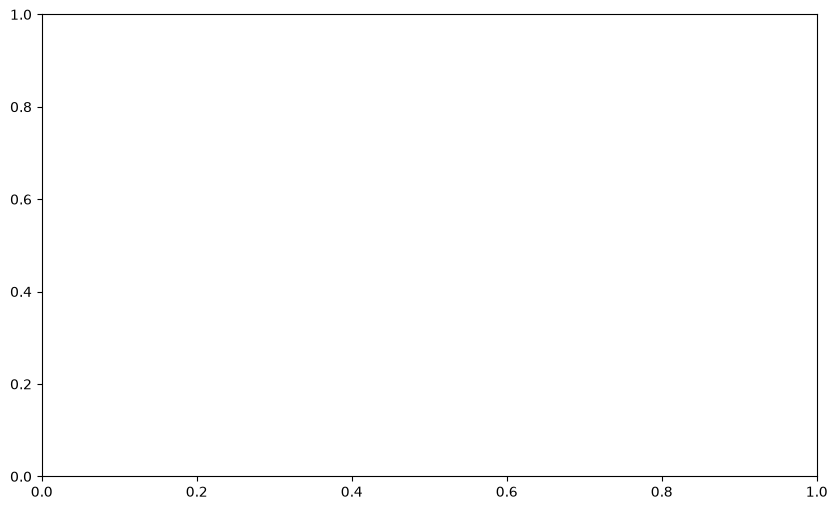

In [43]:
# Set figure details
fig, ax = plt.subplots(figsize=(10, 6))

In [44]:
# Plot a small amount of points (otherwise there's just gonna be too much which might affect visibility)
ax.scatter(y_test[:340], predictions[:340], alpha=0.4, color="#103853", label="Predicted Days")

In [45]:
# Straight line representing models answers
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#af2213", linestyle="--", linewidth=2.7, label="Perfect Predictions")

In [46]:
# Set details for the plot
ax.set_title("Model Evaluation", fontsize=14, fontweight="bold")
ax.set_xlabel("Actual Temperature (°C)", fontsize=12)
ax.set_ylabel("Predicted Temperature (°C)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

In [47]:
# Save the plot
fig.savefig(fname="../media/prediction.png", format="png", dpi=300, bbox_inches="tight")

In [48]:
# Export R2 & Mean Absolute Error values
values = {
    "R2": r2,
    "MAE": mae,
}

with open("../dataset/predictions.json", "w") as file:
    json.dump(values, file, indent=4)